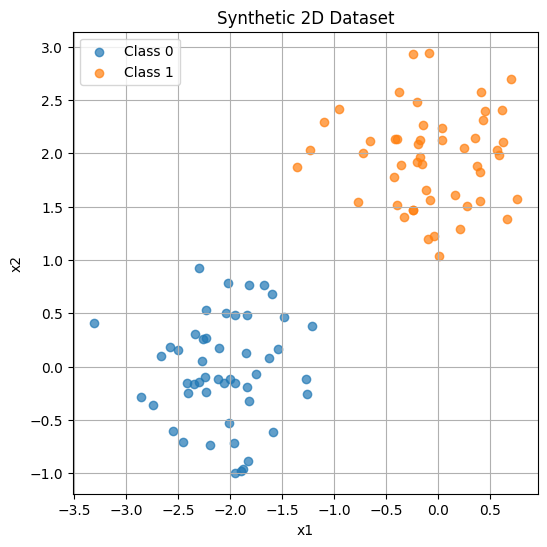

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. PARAMETERS FROM ROLL NUMBER
# ==============================
a = 0   # second last digit
b = 6   # last digit

N = 30 + a + 20               # minimum points per class
rotation_deg = 15 * b    # 90 degrees
noise_std = 0.01 * a     # 0.0

np.random.seed(42)

# ==============================
# 2. DATASET GENERATION
# ==============================
# Class 0
class0 = np.random.randn(N, 2) * 0.5 + np.array([-2, 0])

# Class 1 (before rotation)
class1 = np.random.randn(N, 2) * 0.5 + np.array([2, 0])


# Rotation matrix
theta = np.deg2rad(rotation_deg)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# Rotate class 1
class1 = class1 @ R.T

# Add Gaussian noise (here zero)
class0 += np.random.normal(0, noise_std, class0.shape)
class1 += np.random.normal(0, noise_std, class1.shape)

# Combine dataset
X = np.vstack((class0, class1)) # here it creates a feature matrix
y = np.hstack((-1*np.ones(N), np.ones(N)))  # Perceptron labels

# ==============================
# 3. DATASET VISUALIZATION
# ==============================
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], label="Class 0", alpha=0.7)
plt.scatter(class1[:,0], class1[:,1], label="Class 1", alpha=0.7)
plt.title("Synthetic 2D Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()


In [ ]:
class0

array([[-1.75164292, -0.06913215],
       [-1.67615573,  0.76151493],
       [-2.11707669, -0.11706848],
       [-1.21039359,  0.38371736],
       [-2.23473719,  0.27128002],
       [-2.23170885, -0.23286488],
       [-1.87901886, -0.95664012],
       [-2.86245892, -0.28114376],
       [-2.50641556,  0.15712367],
       [-2.45401204, -0.70615185],
       [-1.26717562, -0.11288815],
       [-1.9662359 , -0.71237409],
       [-2.27219136,  0.05546129],
       [-2.57549679,  0.18784901],
       [-2.30031934, -0.14584687],
       [-2.30085331,  0.92613909],
       [-2.00674861, -0.52885546],
       [-1.58872754, -0.61042182],
       [-1.8955682 , -0.97983506],
       [-2.66409302,  0.09843062],
       [-1.63076671,  0.08568414],
       [-2.05782414, -0.15055185],
       [-2.739261  , -0.3599221 ],
       [-2.23031939,  0.52856111],
       [-1.82819086, -0.88152008],
       [-1.83795802, -0.19254114],
       [-2.338461  ,  0.30583814],
       [-1.48450024,  0.46564006],
       [-2.41960876,

In [ ]:
class1

array([[ 0.21032266,  1.29231463],
       [ 0.40113863,  1.82864274],
       [-0.20202543,  1.91935714],
       [-0.08728891,  2.94309295],
       [ 0.03722296,  2.1287752 ],
       [ 0.01325694,  1.04061439],
       [-1.23162106,  2.0301151 ],
       [-0.15077367,  1.90381952],
       [ 0.58433902,  1.98264412],
       [-0.37596652,  2.57141141],
       [ 0.45469373,  2.39551597],
       [ 0.70092553,  2.70139716],
       [-1.09522781,  2.29342855],
       [ 0.28314886,  1.50473184],
       [ 0.25173783,  2.04982568],
       [-0.03428149,  1.22466828],
       [-0.23679622,  1.46884814],
       [-0.7749672 ,  1.54028788],
       [ 0.16103076,  1.60837335],
       [ 0.61543216,  2.40675861],
       [-0.65357138,  2.11372997],
       [-0.09231693,  1.19625838],
       [-0.39091144,  2.1299414 ],
       [ 0.66022831,  1.38152464],
       [-0.14849234,  2.26097078],
       [-0.1732241 ,  2.12524643],
       [-0.11612685,  1.65998764],
       [ 0.35717571,  2.14653624],
       [-0.23691646,

Perceptron final weights: [0.22780367 0.24676034]
Perceptron bias: 0.0
Perceptron misclassifications per epoch: [3, 1]


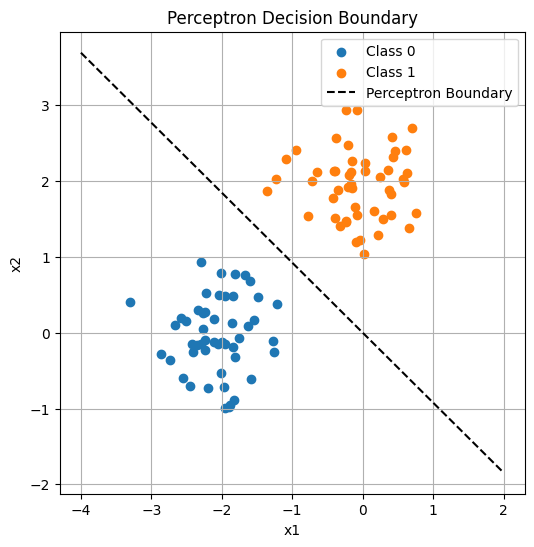

In [ ]:

# ==============================
# 4. PERCEPTRON IMPLEMENTATION
# ==============================
class Perceptron:
    def __init__(self, lr=0.1, epochs=2):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors = []

        for _ in range(self.epochs):
            error = 0
            for xi, yi in zip(X, y):
                update = self.lr * yi * (yi * (np.dot(xi, self.w) + self.b) <= 0)
                self.w += update * xi
                self.b += update
                error += int(update != 0)
            self.errors.append(error)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Train perceptron
perceptron = Perceptron(lr=0.1)
perceptron.fit(X, y)

print("Perceptron final weights:", perceptron.w)
print("Perceptron bias:", perceptron.b)
print("Perceptron misclassifications per epoch:", perceptron.errors)

# ==============================
# 5. PERCEPTRON DECISION BOUNDARY
# ==============================
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], label="Class 0")
plt.scatter(class1[:,0], class1[:,1], label="Class 1")

x_vals = np.linspace(-4,2, 100)
y_vals = -(perceptron.w[0]*x_vals + perceptron.b) / perceptron.w[1]
plt.plot(x_vals, y_vals, 'k--', label="Perceptron Boundary")

plt.title("Perceptron Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()


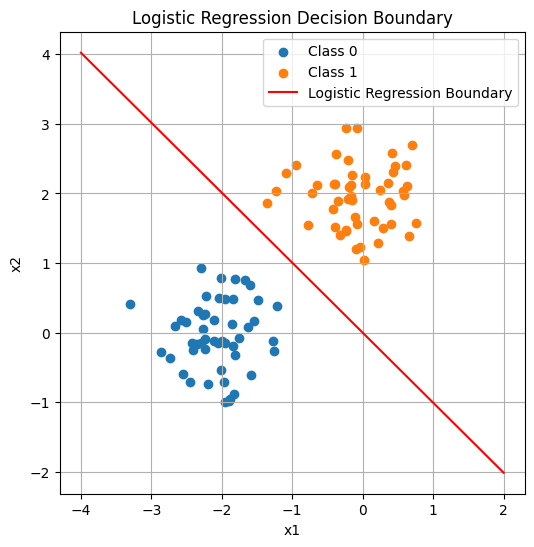

In [ ]:

# ==============================
# 6. LOGISTIC REGRESSION (FROM SCRATCH)
# ==============================
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        y_bin = (y == 1).astype(int)
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear)

            dw = np.dot(X.T, (y_pred - y_bin)) / len(y)
            db = np.mean(y_pred - y_bin)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        return (self.sigmoid(linear) >= 0.5).astype(int)

# Train logistic regression
logreg = LogisticRegression(lr=0.1)
logreg.fit(X, y)

# ==============================
# 7. LOGISTIC REGRESSION BOUNDARY
# ==============================
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], label="Class 0")
plt.scatter(class1[:,0], class1[:,1], label="Class 1")

y_vals = -(logreg.w[0]*x_vals + logreg.b) / logreg.w[1]
plt.plot(x_vals, y_vals, 'r-', label="Logistic Regression Boundary")

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()
